<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/Mini_Project_Diabetes_Risk_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Diabetes is a chronic disease that affects millions of people globally and can lead to severe health complications like heart disease, kidney failure, and vision loss. Early detection of diabetes risk is crucial for lifestyle intervention and clinical management. Machine learning models can analyze various demographic, behavioral, and health history indicators to flag high-risk individuals early.

Import Data

In [1]:
#Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report
)

In [3]:
# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [11]:
print("--- Step 4: Loading Dataset ---")
dataset_path = 'diabetes_012_health_indicators.csv'
df_pop = pd.read_csv(dataset_path)
row_count = df_pop.shape[0]  # Returns both (rows, columns) as a tuple
col_count = df_pop.shape[1]  # Get the number of columns
total_cells = df_pop.size
print(f"Dataset has {row_count} rows and {col_count} columns. Total cells: {total_cells}")

--- Step 4: Loading Dataset ---
Dataset has 253680 rows and 22 columns. Total cells: 5580960


In [12]:
df = df_pop.sample(n=20000, random_state=42).reset_index(drop=True)

print(f"Sample dataset shape: {df.shape}")

Sample dataset shape: (20000, 22)


In [13]:
print(f"Dataset Shape: {df.shape}")
print(df.head())

Dataset Shape: (20000, 22)
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     0.0       0.0        1.0  21.0     0.0     0.0   
1           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
2           0.0     0.0       0.0        1.0  24.0     0.0     0.0   
3           0.0     0.0       0.0        1.0  27.0     1.0     0.0   
4           0.0     0.0       1.0        1.0  31.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     1.0  ...            1.0   
1                   0.0           1.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     0.0  ...            1.0   
4                   0.0           0.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       3.0       7.0       0.0  0.0

In [14]:
#Data Preprocessing and cleaning
#Check missing values
print(f"Missing Values: {df.isnull().sum()}")

Missing Values: Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [17]:
#no null values, still doing fillna
df.fillna(df.median(), inplace=True)

In [19]:
# Remove exact duplicates
initial_len = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_len - df.shape[0]} duplicate records.")

Removed 438 duplicate records.


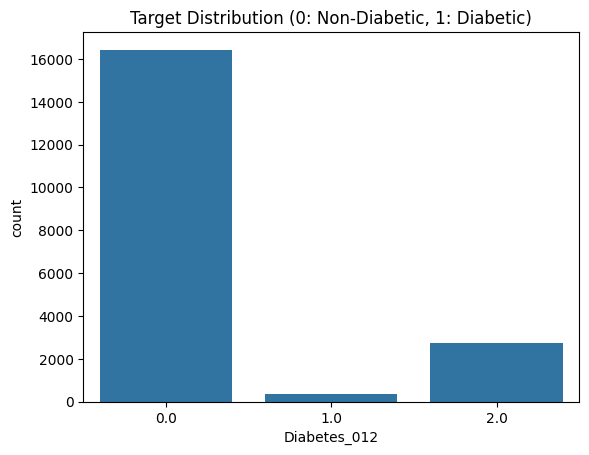

In [20]:
# 1. Target Distribution Plot
sns.countplot(x='Diabetes_012', data=df)
plt.title('Target Distribution (0: Non-Diabetic, 1: Diabetic)')

plt.show()

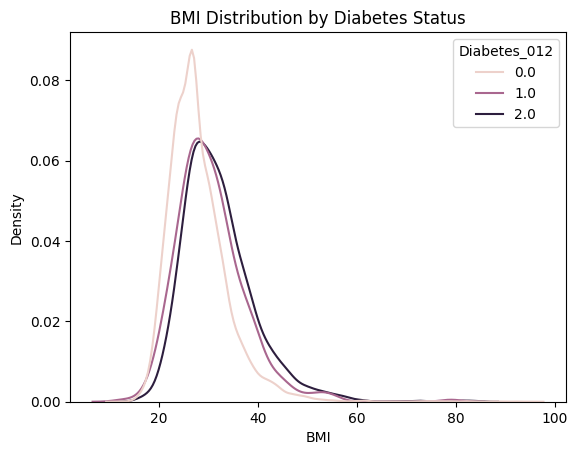

In [21]:
# 2. BMI Distribution (KDE Plot)
sns.kdeplot(data=df, x='BMI', hue='Diabetes_012', common_norm=False)
plt.title('BMI Distribution by Diabetes Status')
plt.show()

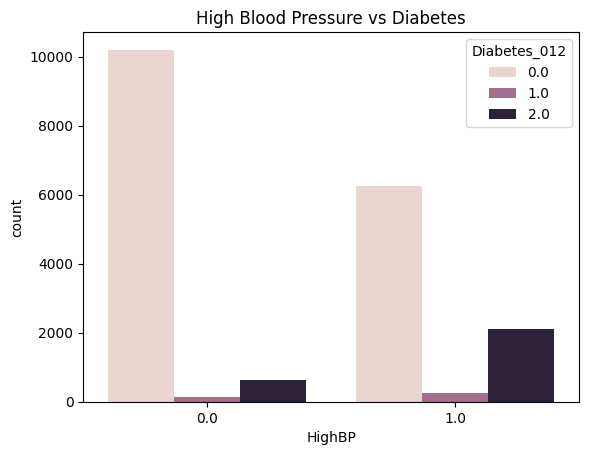

In [22]:
# 3. High Blood Pressure vs Diabetes Countplot
sns.countplot(x='HighBP', hue='Diabetes_012', data=df)
plt.title('High Blood Pressure vs Diabetes')
plt.show()

Text(0.5, 1.0, 'Top Feature Correlation Heatmap')

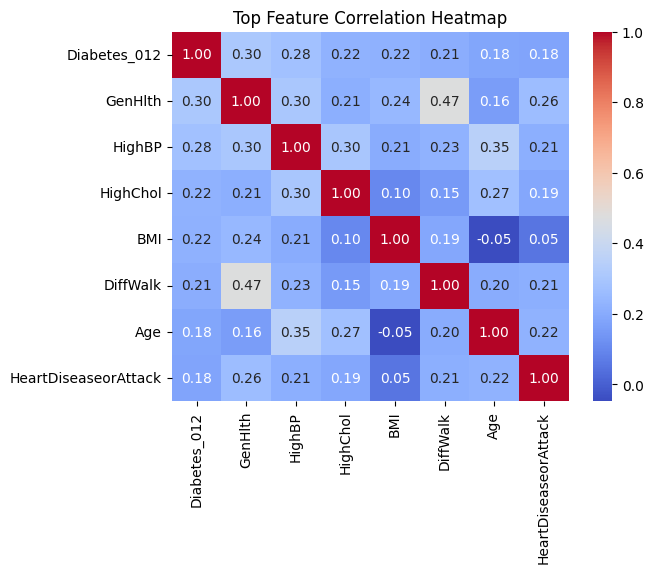

In [23]:
# 4. Correlation Heatmap (Top 8 correlated features)
top_corr = df.corr()['Diabetes_012'].abs().nlargest(8).index
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top Feature Correlation Heatmap')

In [24]:
#Box plot draw
def detect_remove_outliers(df,column):
        plt.boxplot(df[column])
        plt.title("Before outlier for " + column)
        plt.show()

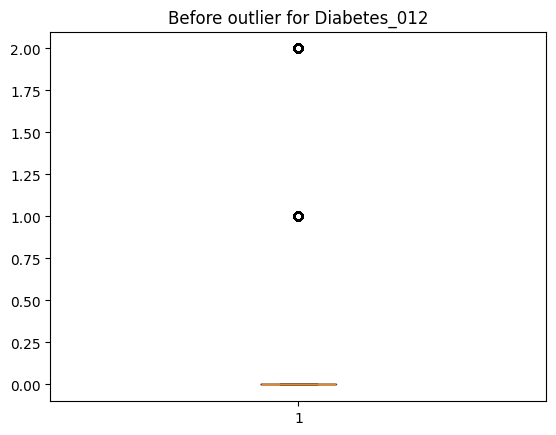

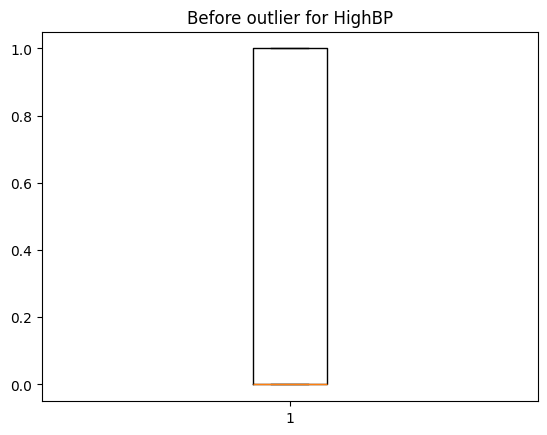

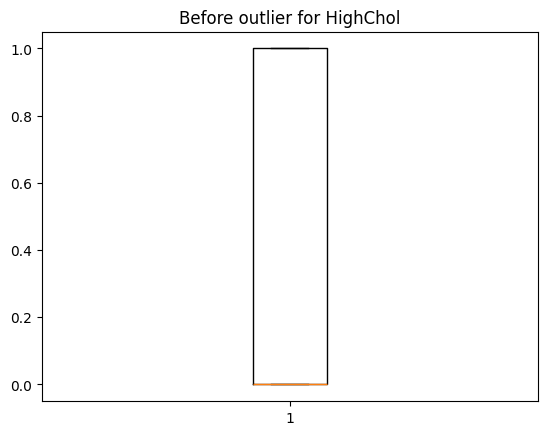

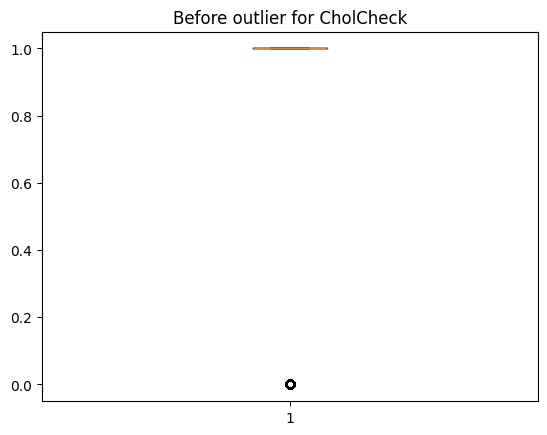

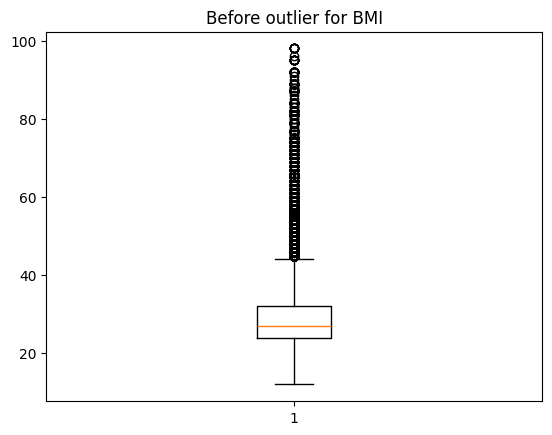

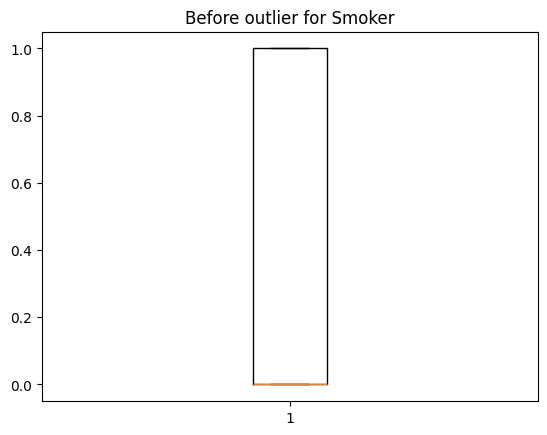

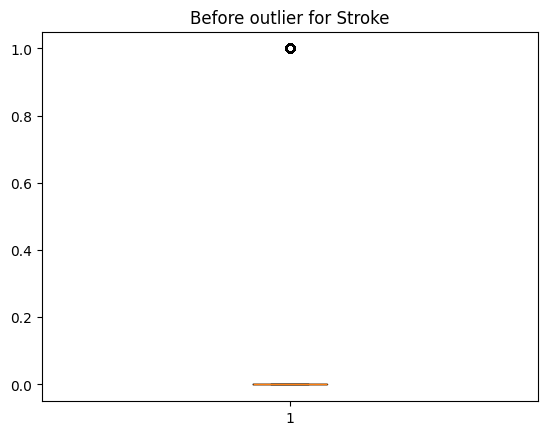

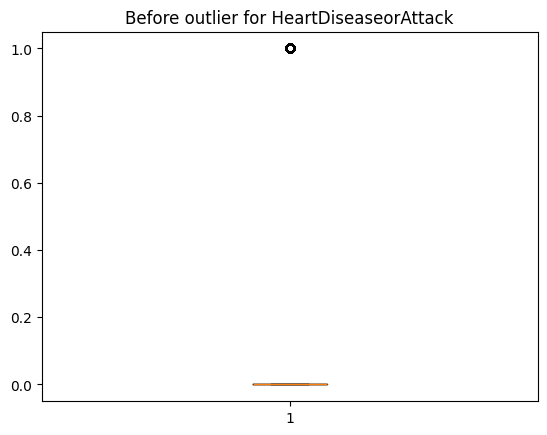

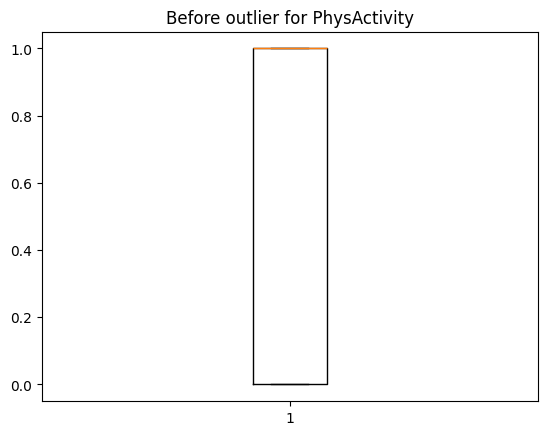

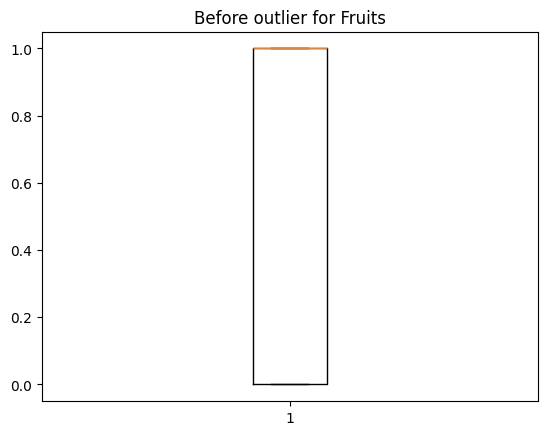

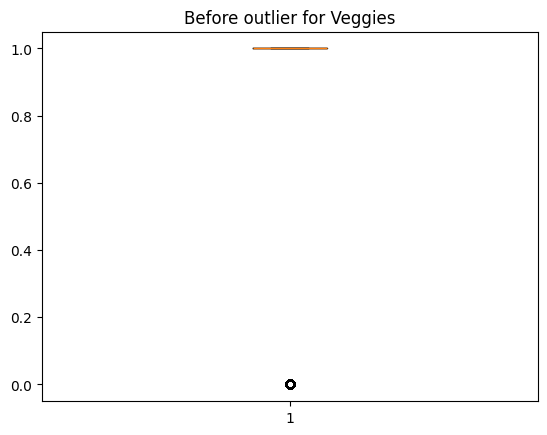

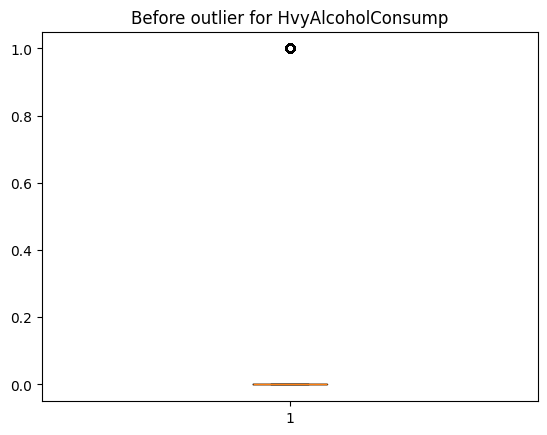

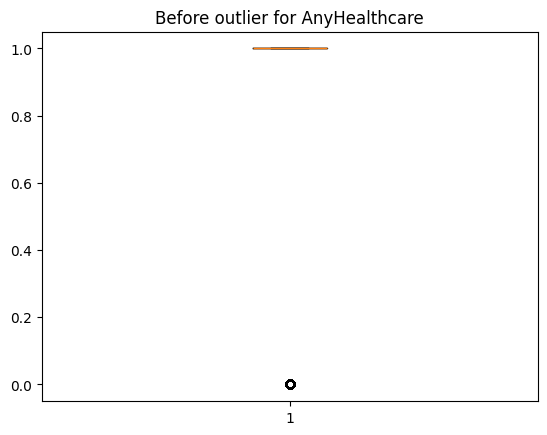

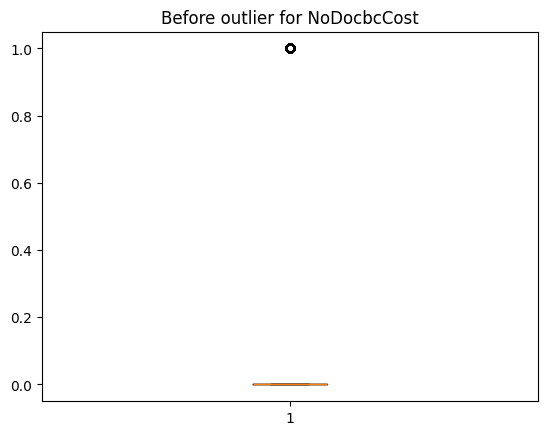

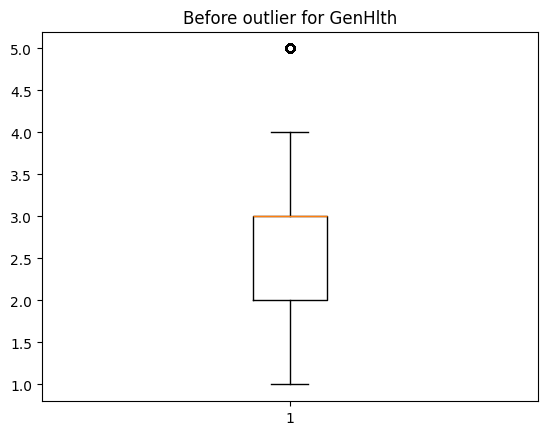

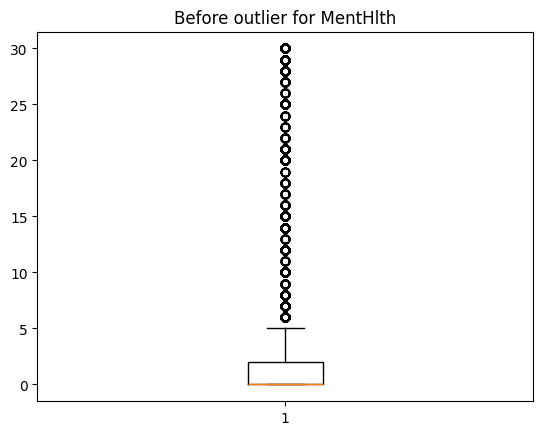

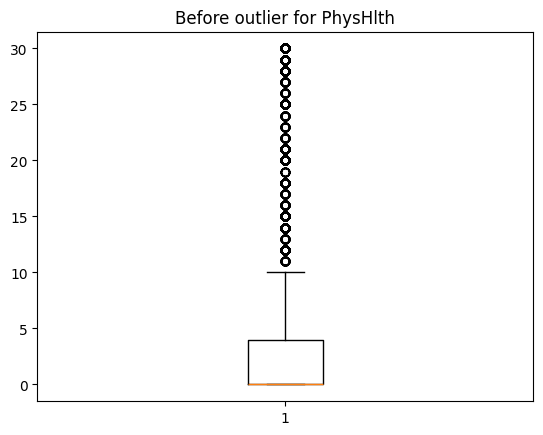

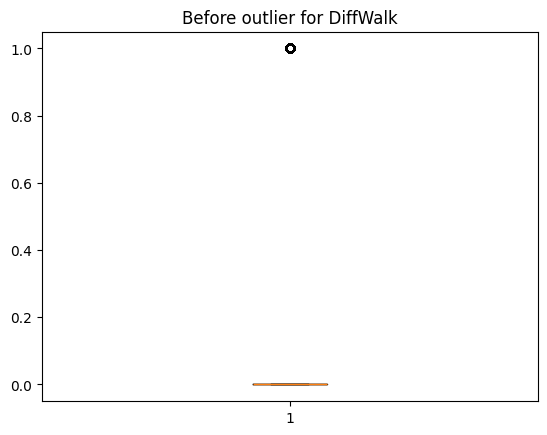

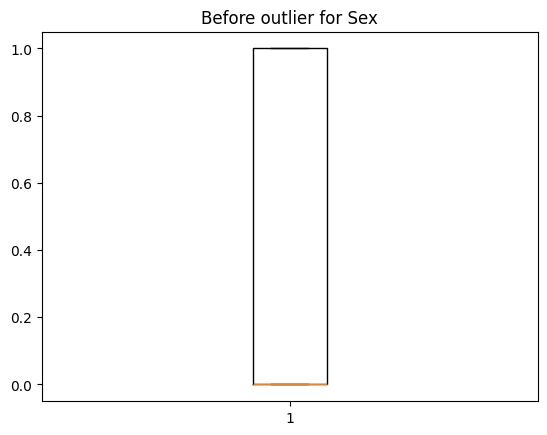

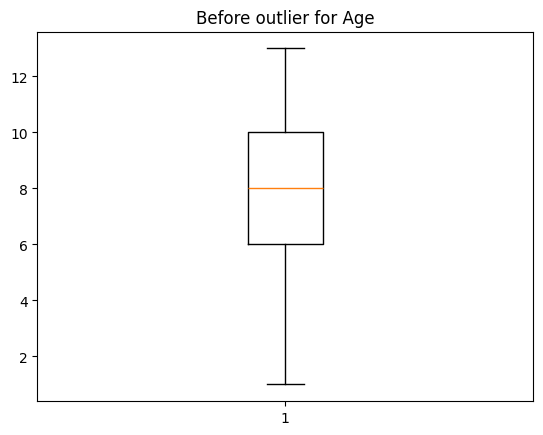

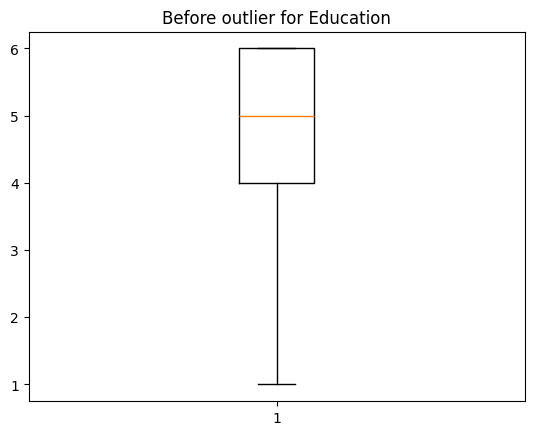

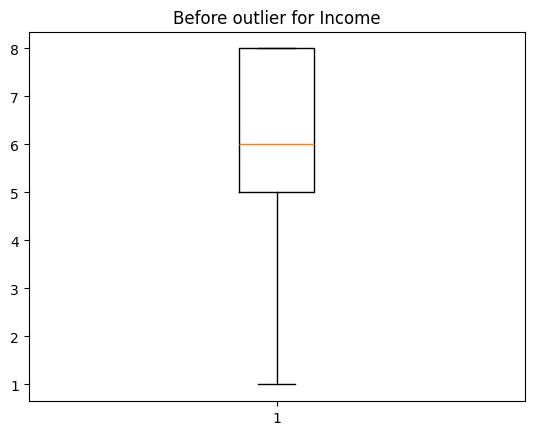

EXCEPTION COLIMNS []


In [ ]:
ex_col=[]
for x in df.columns:
   try:
        detect_remove_outliers(df , x)
   except:
       ex_col.append(x)
print("EXCEPTION COLIMNS",ex_col)

In [25]:
def draw_hist(df,column):
        sns.kdeplot(df[column],color='blue', linewidth=2)
        plt.title("Distribution of " + column)
        plt.show()

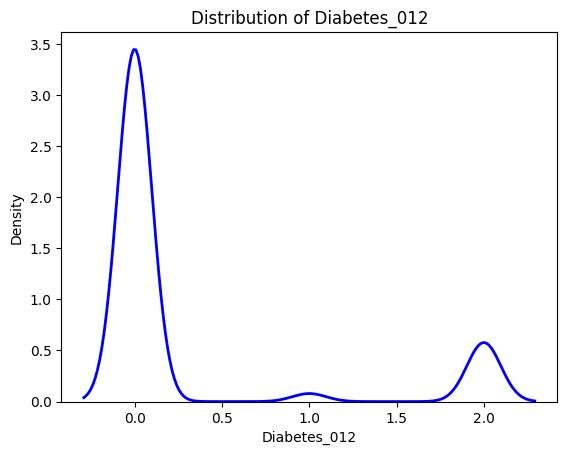

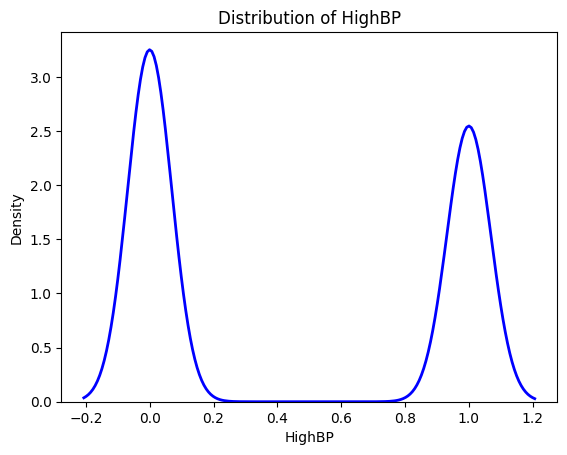

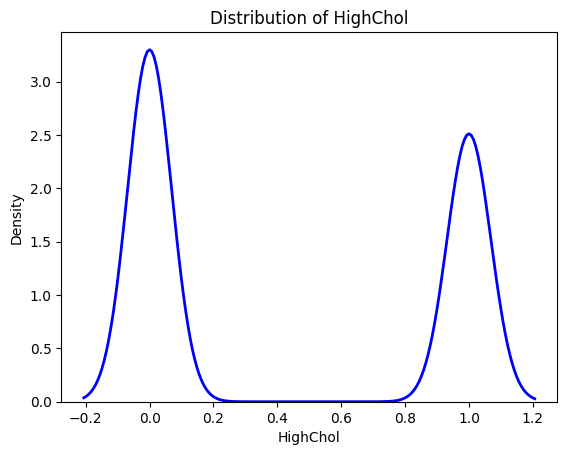

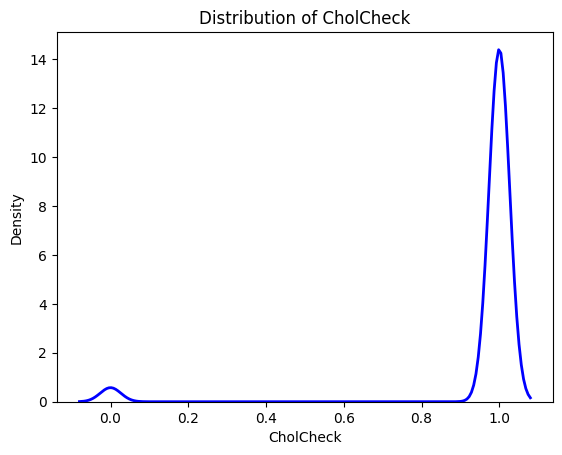

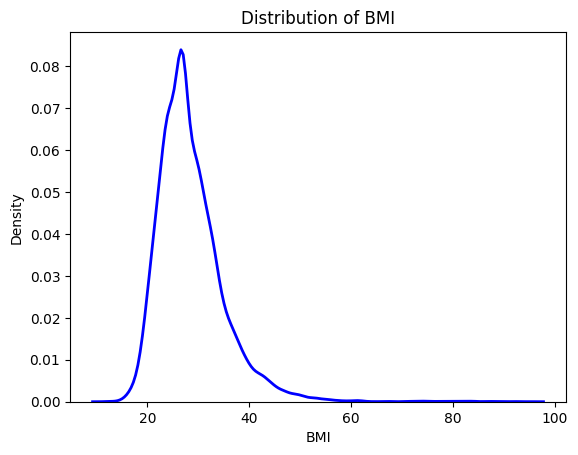

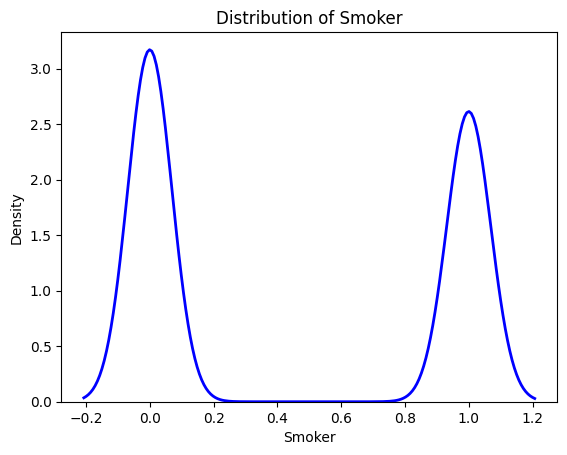

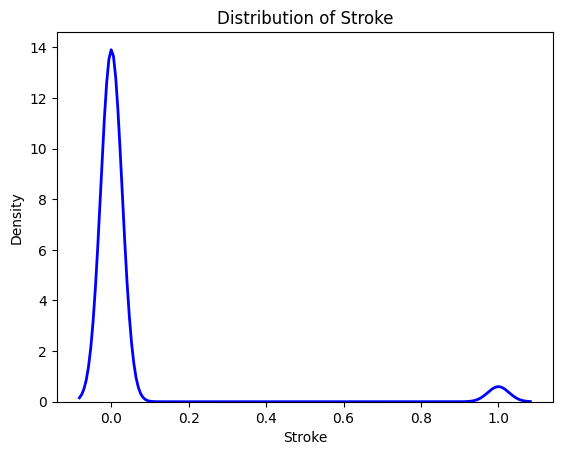

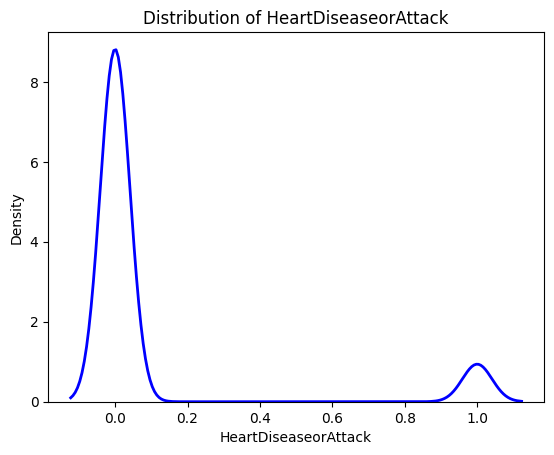

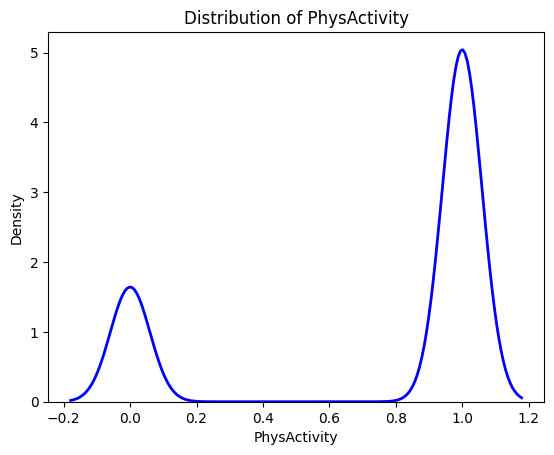

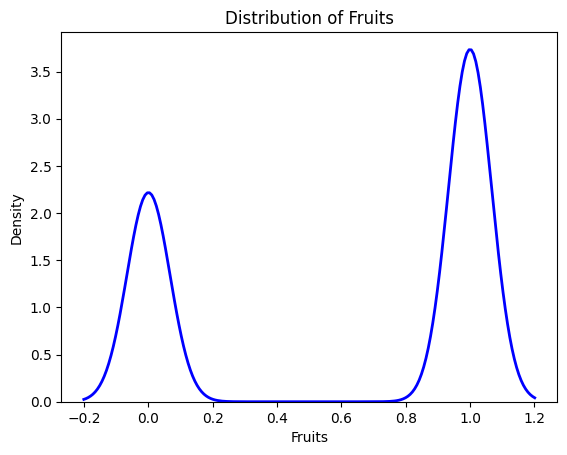

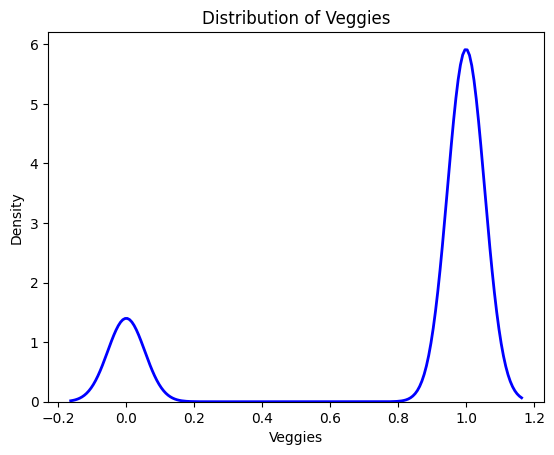

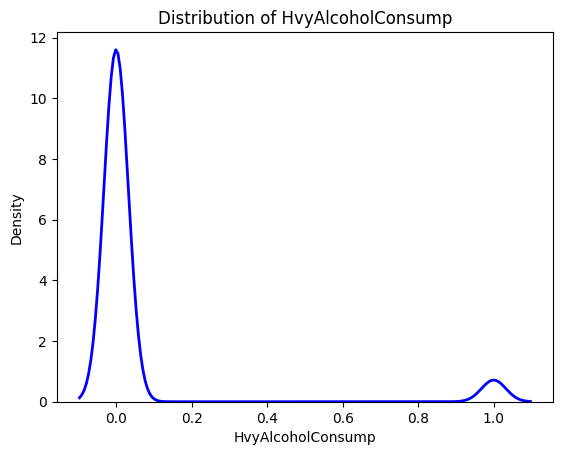

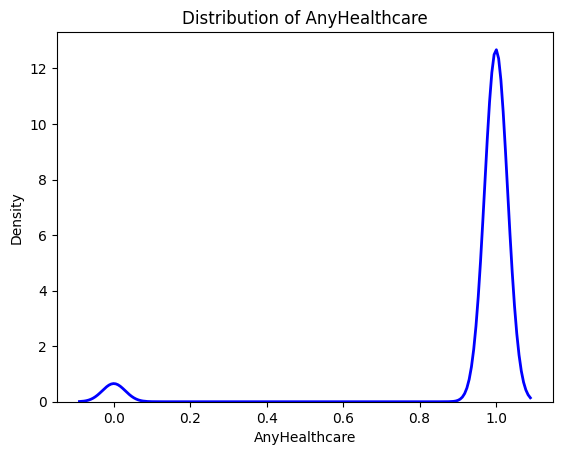

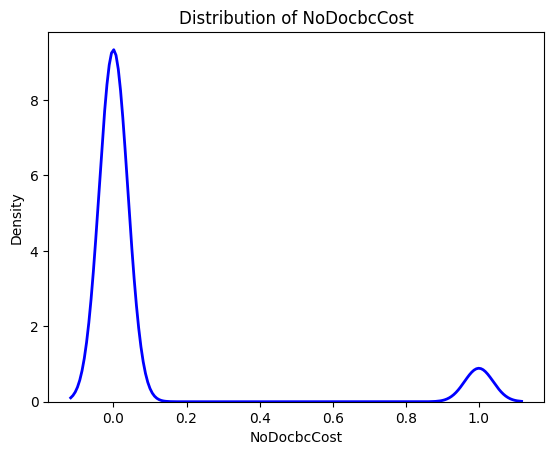

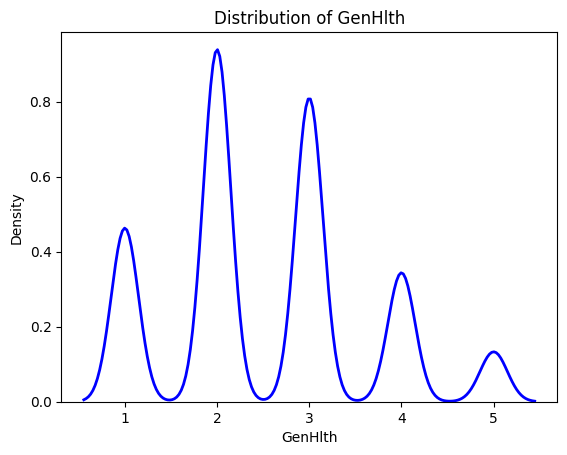

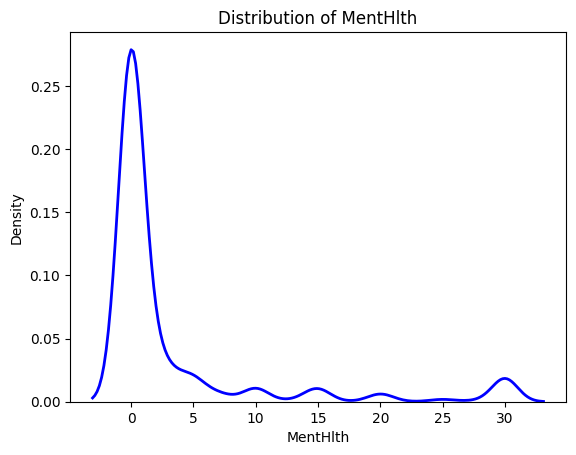

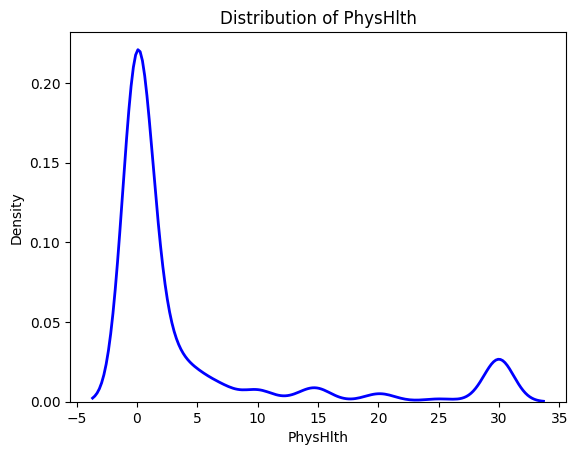

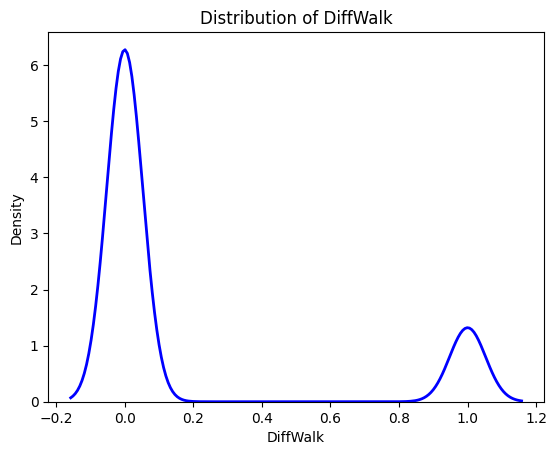

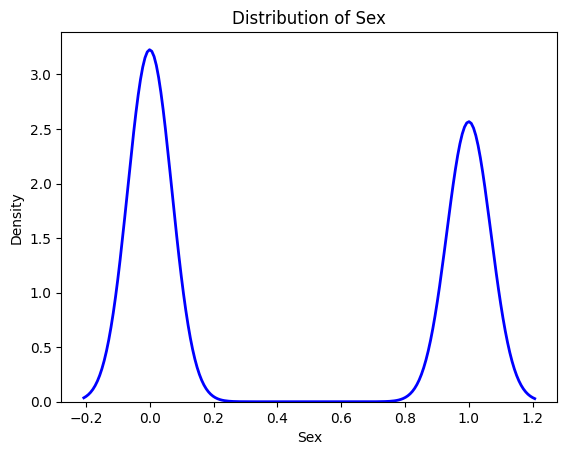

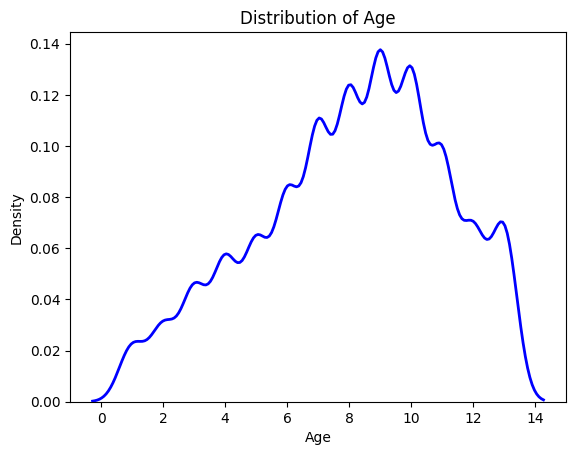

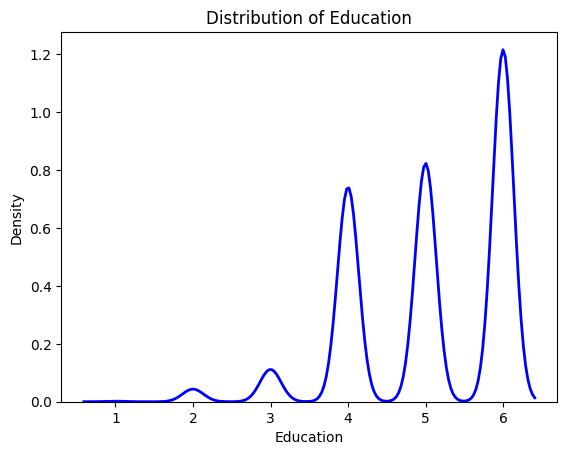

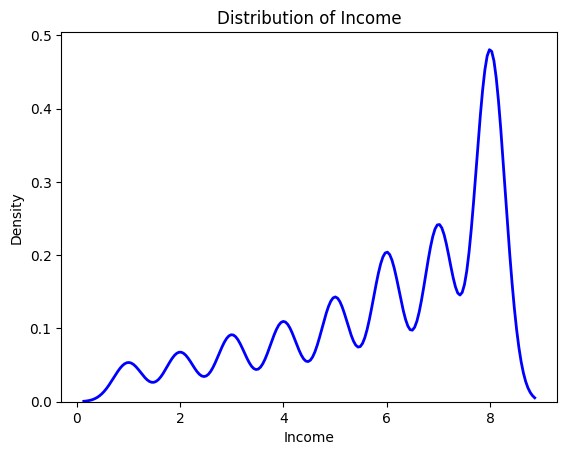

EXCEPTION COLIMNS []


In [26]:
ex_col=[]
for x in df.columns:
   try:
        draw_hist(df , x)
   except:
       ex_col.append(x)
print("EXCEPTION COLIMNS",ex_col)

In [27]:
# Cap outliers in continuous feature 'BMI' using Interquartile Range (IQR)
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['BMI'] = np.clip(df['BMI'], lower_bound, upper_bound)

In [28]:
# Cap outliers in continuous feature 'BMI' using Interquartile Range (IQR)
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['BMI'] = np.clip(df['BMI'], lower_bound, upper_bound)

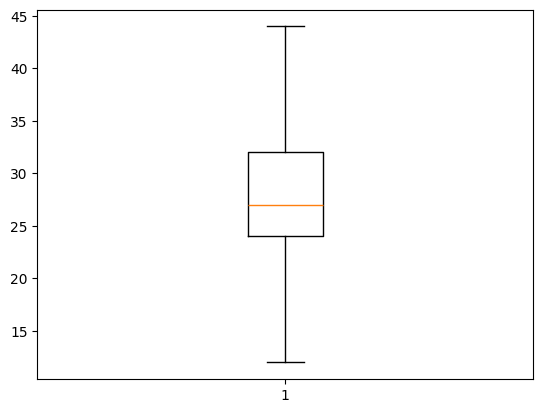

In [29]:
    plt.boxplot(df['BMI'])
    plt.show()

In [30]:
col_names=df.columns.tolist()
col_names

['Diabetes_012',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [31]:
# Cap outliers in continuous feature 'BMI' using Interquartile Range (IQR)
Q1 = df['PhysHlth'].quantile(0.25)
Q3 = df['PhysHlth'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['PhysHlth'] = np.clip(df['PhysHlth'], lower_bound, upper_bound)


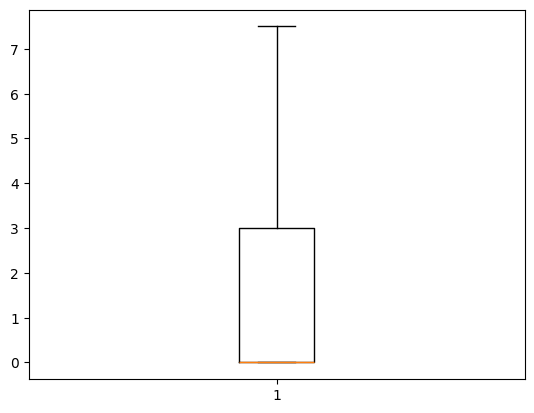

In [32]:
  plt.boxplot(df['PhysHlth'])
  plt.show()

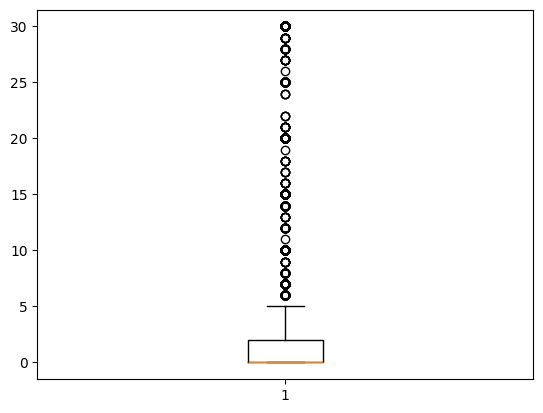

In [33]:
  plt.boxplot(df['MentHlth'])
  plt.show()

In [34]:
# Cap outliers in continuous feature 'BMI' using Interquartile Range (IQR)
Q1 = df['MentHlth'].quantile(0.25)
Q3 = df['MentHlth'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['MentHlth'] = np.clip(df['MentHlth'], lower_bound, upper_bound)

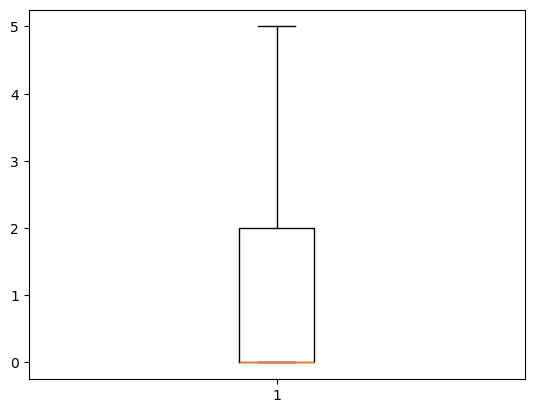

In [35]:
  plt.boxplot(df['MentHlth'])
  plt.show()

In [36]:
#Feature Engineering & Feature Selection
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']



In [37]:
# Selecting top 15 features using SelectKBest (Chi-Square method)
selector = SelectKBest(score_func=chi2, k=15)
X_new = selector.fit_transform(X, y)
selected_columns = X.columns[selector.get_support()]
print("Selected Features:", list(selected_columns))

X = X[selected_columns]

Selected Features: ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']


In [38]:
#Split Test and Train Data
print("Train-Test Split: ")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train-Test Split: 
Train Shape: (15649, 15), Test Shape: (3913, 15)


In [39]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

In [40]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)
    results[name] = acc

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions))
    print("\n")

=== Logistic Regression ===
Accuracy: 0.8436
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91      3288
         1.0       0.00      0.00      0.00        75
         2.0       0.52      0.18      0.26       550

    accuracy                           0.84      3913
   macro avg       0.46      0.38      0.39      3913
weighted avg       0.80      0.84      0.80      3913



=== Decision Tree ===
Accuracy: 0.7626
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86      3288
         1.0       0.02      0.03      0.03        75
         2.0       0.29      0.33      0.31       550

    accuracy                           0.76      3913
   macro avg       0.40      0.40      0.40      3913
weighted avg       0.78      0.76      0.77      3913





/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


=== Random Forest ===
Accuracy: 0.8349
              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91      3288
         1.0       0.00      0.00      0.00        75
         2.0       0.45      0.20      0.28       550

    accuracy                           0.83      3913
   macro avg       0.44      0.39      0.40      3913
weighted avg       0.79      0.83      0.80      3913



=== Support Vector Machine ===
Accuracy: 0.8459
              precision    recall  f1-score   support

         0.0       0.85      0.99      0.92      3288
         1.0       0.00      0.00      0.00        75
         2.0       0.59      0.10      0.18       550

    accuracy                           0.85      3913
   macro avg       0.48      0.36      0.36      3913
weighted avg       0.80      0.85      0.79      3913





/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


=== k-Nearest Neighbors ===
Accuracy: 0.8341
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91      3288
         1.0       0.25      0.01      0.03        75
         2.0       0.44      0.23      0.30       550

    accuracy                           0.83      3913
   macro avg       0.52      0.40      0.41      3913
weighted avg       0.79      0.83      0.81      3913





In [43]:
results = {}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    # Added average='weighted' to handle multiclass labels
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

# Display results comparison table
results_df = pd.DataFrame(results).T
print("\n--- Model Evaluation Comparison ---")
print(results_df.round(4))


--- Model Evaluation Comparison ---
                        Accuracy  Precision  Recall  F1-Score
Logistic Regression       0.8436     0.7954  0.8436    0.8050
Decision Tree             0.7626     0.7750  0.7626    0.7685
Random Forest             0.8349     0.7873  0.8349    0.8025
Support Vector Machine    0.8459     0.7996  0.8459    0.7942
k-Nearest Neighbors       0.8341     0.7947  0.8341    0.8061


Among the 5 evaluated algorithms, k-Nearest Neighbors (KNN) and Logistic Regression proved to be the top-performing models, delivering the highest balanced F1-scores (~80.6%). While SVM yielded a marginally higher overall accuracy (84.59%), Logistic Regression and KNN provided a better balance between detecting true positive risk cases and minimizing false alarms. A standalone Decision Tree proved unsuitable for this dataset due to lower accuracy (76.26%)